In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("C:/Users/Ajsha/Downloads/ProfEvaltnsBeautyPublic.csv")
print(df.head())

   tenured  profnumber  minority  age  beautyf2upper  beautyflowerdiv  \
0        0           1         1   36              6                5   
1        1           2         0   59              2                4   
2        1           3         0   51              5                5   
3        1           4         0   40              4                2   
4        0           5         0   31              9                7   

   beautyfupperdiv  beautym2upper  beautymlowerdiv  beautymupperdiv  ...  \
0                7              6                2                4  ...   
1                4              3                2                3  ...   
2                2              3                2                3  ...   
3                5              2                3                3  ...   
4                9              6                7                6  ...   

   nonenglish  onecredit  percentevaluating  profevaluation  students  \
0           0          0       

In [2]:
# Q1: Duplicate cases and age analysis

# Identify duplicate cases using professor ID
duplicates = df[df.duplicated(subset="profnumber", keep=False)]

print("Duplicate cases:")
print(duplicates["profnumber"].value_counts().head())

# Age statistics using all observations
print("\nAll Observations")
print("Number of observations:", len(df))
print("Mean Age:", round(df["age"].mean(), 4))
print("Standard Deviation:", round(df["age"].std(), 4))

# Keep one observation for each instructor
df_unique = df.drop_duplicates(subset="profnumber")

# Age statistics using one observation per instructor
print("\nUnique Instructors")
print("Number of instructors:", len(df_unique))
print("Mean Age:", round(df_unique["age"].mean(), 4))
print("Standard Deviation:", round(df_unique["age"].std(), 4))

Duplicate cases:
profnumber
34    13
50    13
82    11
58    10
10    10
Name: count, dtype: int64

All Observations
Number of observations: 463
Mean Age: 48.365
Standard Deviation: 9.8027

Unique Instructors
Number of instructors: 94
Mean Age: 47.5532
Standard Deviation: 10.2565


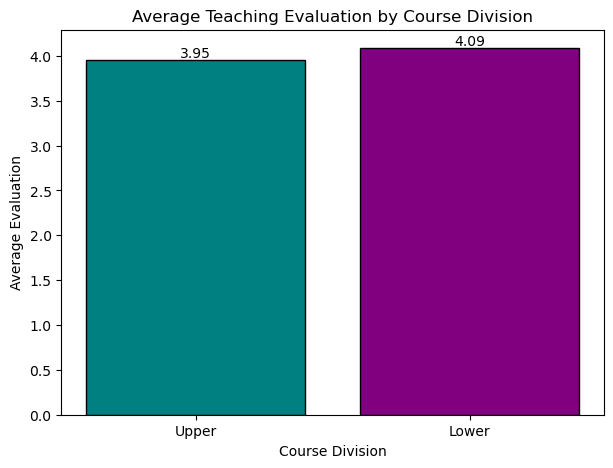

In [3]:
# Q2: Bar chart for average teaching evaluation

avg = df.groupby("lower")["courseevaluation"].mean()

plt.figure(figsize=(7, 5))
bars = plt.bar(["Upper", "Lower"], [avg[0], avg[1]],
               color=["teal", "purple"], edgecolor="black")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(), f"{bar.get_height():.2f}",
             ha="center", va="bottom")

plt.xlabel("Course Division")
plt.ylabel("Average Evaluation")
plt.title("Average Teaching Evaluation by Course Division")
plt.show()

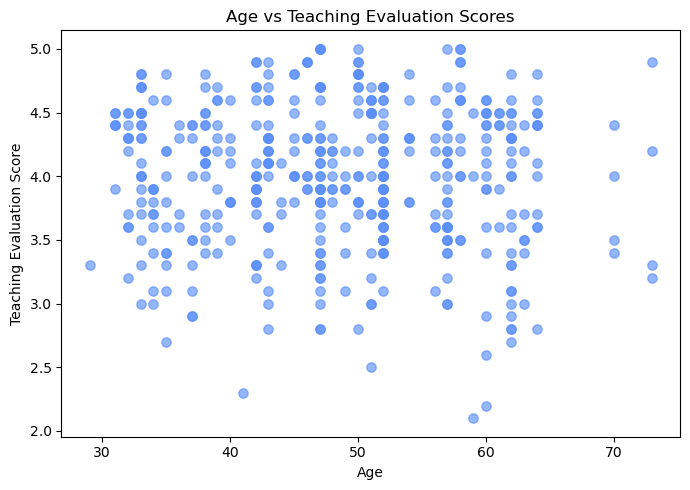

In [4]:
# Q3: Relationship between age and teaching evaluation

plt.figure(figsize=(7, 5))

plt.scatter(df["age"], df["courseevaluation"],
            color="#5B8FF9", s=45, alpha=0.65)

plt.xlabel("Age")
plt.ylabel("Teaching Evaluation Score")
plt.title("Age vs Teaching Evaluation Scores")

plt.tight_layout()
plt.show()

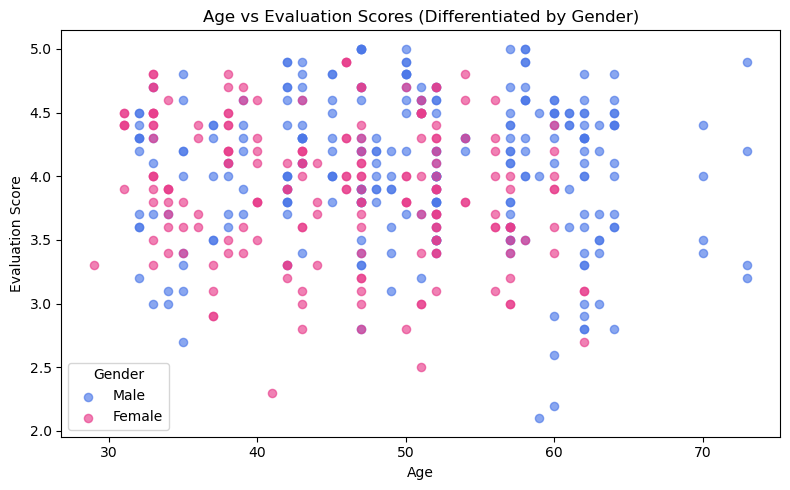

In [5]:
# Q4: Relationship between age and teaching evaluation by gender

plt.figure(figsize=(8, 5))

male = df[df["female"] == 0]
female = df[df["female"] == 1]

plt.scatter(male["age"], male["courseevaluation"],
            color="#4C78E8", s=35, alpha=0.65, label="Male")

plt.scatter(female["age"], female["courseevaluation"],
            color="#E83E8C", s=35, alpha=0.65, label="Female")

plt.xlabel("Age")
plt.ylabel("Evaluation Score")
plt.title("Age vs Evaluation Scores (Differentiated by Gender)")
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

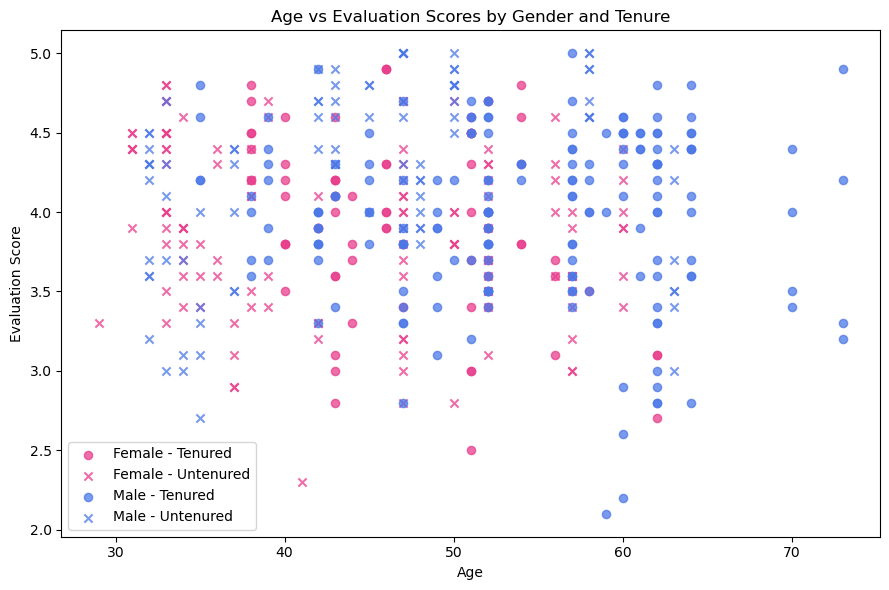

In [6]:
# Q5: Age vs evaluation scores by gender and tenure

plt.figure(figsize=(9, 6))

plt.scatter(df[(df["female"] == 1) & (df["tenured"] == 1)]["age"],
            df[(df["female"] == 1) & (df["tenured"] == 1)]["courseevaluation"],
            color="#E83E8C", marker="o", s=35, alpha=0.75,
            label="Female - Tenured")

plt.scatter(df[(df["female"] == 1) & (df["tenured"] == 0)]["age"],
            df[(df["female"] == 1) & (df["tenured"] == 0)]["courseevaluation"],
            color="#E83E8C", marker="x", s=35, alpha=0.75,
            label="Female - Untenured")

plt.scatter(df[(df["female"] == 0) & (df["tenured"] == 1)]["age"],
            df[(df["female"] == 0) & (df["tenured"] == 1)]["courseevaluation"],
            color="#4C78E8", marker="o", s=35, alpha=0.75,
            label="Male - Tenured")

plt.scatter(df[(df["female"] == 0) & (df["tenured"] == 0)]["age"],
            df[(df["female"] == 0) & (df["tenured"] == 0)]["courseevaluation"],
            color="#4C78E8", marker="x", s=35, alpha=0.75,
            label="Male - Untenured")

plt.xlabel("Age")
plt.ylabel("Evaluation Score")
plt.title("Age vs Evaluation Scores by Gender and Tenure")
plt.legend()

plt.tight_layout()
plt.show()